# ERA5 Intermediate Processing

**Purpose**: Code for combining the wind velocity data from the ERA5 model so to match the time period of the mitgcm CASE model 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean
from scipy.interpolate import interp1d

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart

Set data analysis parameters

In [3]:
# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/era5/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

Load mitgcm data netcdf files 

In [4]:
# Obtain filename paths
filename_u_2016 = PATH + "ERA5_u10m_CCS_region_2016.nc"
filename_u_2017 = PATH + "ERA5_u10m_CCS_region_2017.nc"
filename_v_2016 = PATH + "ERA5_v10m_CCS_region_2016.nc"
filename_v_2017 = PATH + "ERA5_v10m_CCS_region_2017.nc"

# Generate the nc data structure
nc_u_2016 = Dataset(filename_u_2016, 'r')
nc_u_2017 = Dataset(filename_u_2017, 'r')
nc_v_2016 = Dataset(filename_v_2016, 'r')
nc_v_2017 = Dataset(filename_v_2017, 'r')

# Extract data variables
lon = nc_u_2016.variables['lon'][:]
lat = nc_u_2016.variables['lat'][:]

time_2016 = num2date(nc_u_2016.variables['time'][:], nc_u_2016.variables['time'].units)
time_2017 = num2date(nc_u_2017.variables['time'][:], nc_u_2017.variables['time'].units)

u_2016  = nc_u_2016.variables['u10m'][:]
u_2017  = nc_u_2017.variables['u10m'][:]
v_2016 = nc_v_2016.variables['v10m'][:]
v_2017 = nc_v_2017.variables['v10m'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_2016_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time_2016])
time_2017_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time_2017])

Combine arrays 

In [5]:
# Append the u10m arrays
u = np.concatenate([u_2016, u_2017], axis=0)

# Append the v10m arrays
v = np.concatenate([v_2016, v_2017], axis=0)

# Append the time arrays
time_dt = np.concatenate([time_2016_dt, time_2017_dt], axis=0)

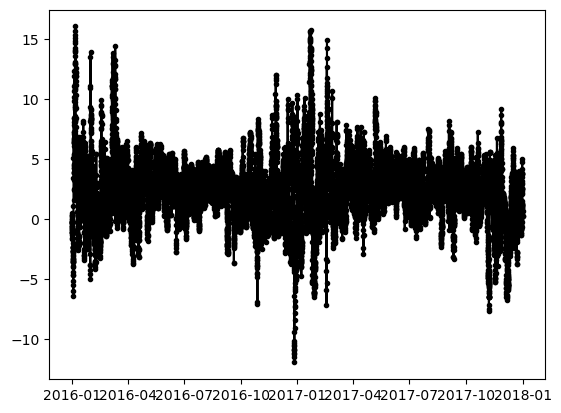

In [7]:
plt.plot(time_dt, u[:,0,0],'k.-')

Save the new data into a netCDF file

In [6]:
# Save variables in data arrays
U_wind = xr.DataArray(data=u, 
                    dims=['time','lat','lon'],
                    coords=dict(time=time_dt,lat=lat,lon=lon),
                    attrs=dict(
                        description='10 metre eastward wind component.',
                        units='m s-1'
                        )
)

V_wind = xr.DataArray(data=v, 
                    dims=['time','lat','lon'],
                    coords=dict(time=time_dt,lat=lat,lon=lon),
                    attrs=dict(
                        description='10 metre northward wind component.',
                        units='m s-1'
                        )
)

# Create a data set from data arrays 
data = xr.Dataset({'U_wind':U_wind,'V_wind':V_wind})
file_path = PATH + "/ERA5_wind_vel_2016-2017.nc"

# Check if file exists, then delete it
if os.path.exists(file_path):
    os.remove(file_path)

# Create netcdf file 
data.to_netcdf(file_path,mode='w')